This practice aims to your understanding of Artificial Neural Networks (ANNs) by 
implementing Binary Classification using an optimized model. The following key concepts 
will be covered:
 1. Forward Propagation
 2. Backpropagation
 3. Loss Functions
 4. Optimization using Gradient Descent and Learning Rate
 5. Implementation of Binary Classification
 6. Weight Initialization

Step 1: Import required libraries

In [19]:
import numpy as np
import pandas as pd

Step 2: Load and preprocess the dataset

In [20]:
data = pd.read_csv(r"D:\Machine Learning Dataset\mushrooms.csv")

In [21]:
# Convert all categorical columns to numeric using one-hot encoding
data_encoded = pd.get_dummies(data, drop_first=True)

In [22]:
# Assuming 'class_p' is the target column after encoding ('p' = poisonous)
# If your dataset encodes differently, print data_encoded.columns() to check
y = data_encoded['class_p'].values.reshape(-1, 1)
X = data_encoded.drop('class_p', axis=1).values
# Normalize the feature values for better convergence
X = (X - X.mean(axis=0)) / X.std(axis=0)

Step 3: Initialize parameters

In [23]:
input_size = X.shape[1]   # number of input features
hidden_size = 5           # number of hidden neurons
output_size = 1           # binary output

In [24]:
# Weight Initialization (small random values)
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

Step 4: Define helper function

In [25]:
#Sigmoid activation function
def sigmoid(z):
   return 1 / (1 + np.exp(-z))
# Derivative of sigmoid
def sigmoid_derivative(a):
   return a * (1 - a)

Step 5: Training parameters

In [26]:
learning_rate = 0.01
epochs = 100

Step 6: Training loop

In [27]:
for epoch in range(epochs):
    # ---- Forward Propagation ---
    Z1 = np.dot(X, W1) + b1           # Linear step for hidden layer
    A1 = sigmoid(Z1)                  # Activation for hidden layer
    Z2 = np.dot(A1, W2) + b2          # Linear step for output layer
    A2 = sigmoid(Z2)                  # Activation for output layer (predicted value)
    m = y.shape[0]  # number of samples
    loss = (-1/m) * np.sum(y*np.log(A2 + 1e-8) + (1-y)*np.log(1 - A2 + 1e-8))
    # ---- Backpropagation ---
    dZ2 = A2 - y                      # Derivative of loss w.r.t Z2
    dW2 = (1/m) * np.dot(A1.T, dZ2)   # Gradient for W2
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
    
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
    
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")
#prediction and accuracy
predictions = (A2 > 0.5).astype(int)
accuracy = np.mean(predictions == y) * 100
print(f"\nTraining Accuracy: {accuracy:.2f}%")

Epoch 0 | Loss: 0.6939
Epoch 10 | Loss: 0.6937
Epoch 20 | Loss: 0.6936
Epoch 30 | Loss: 0.6935
Epoch 40 | Loss: 0.6934
Epoch 50 | Loss: 0.6933
Epoch 60 | Loss: 0.6932
Epoch 70 | Loss: 0.6931
Epoch 80 | Loss: 0.6930
Epoch 90 | Loss: 0.6930

Training Accuracy: 51.80%


Task
 1. Implemented an ANN model with Forward and Backpropagation.
 2. Applied it to Multi Class Classification.
 3. Used activation function of your own choice.
 4. Optimized using any optimizer.
 5. Weight Initialization.
 6. Evaluated model performance using accuracy score.
 7. Plotted loss curve to analyze convergence 

Step 1: Import required libraries

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

Step 2: Load and preprocess the dataset

In [40]:
data = pd.read_csv(r"D:\Machine Learning Dataset\mushrooms.csv")

# Check the original target column
print("Original target column:", data.columns[0])
print("Unique values in target:", data[data.columns[0]].unique())

# Convert categorical data to numerical using Label Encoding for multi-class
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data[data.columns[0]]).reshape(-1, 1)

# One-hot encode features
X = data.drop(data.columns[0], axis=1)
X = pd.get_dummies(X, drop_first=True).values

# Normalize features
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Original target column: class
Unique values in target: ['p' 'e']


Step 3: Initialize parameters

In [41]:
input_size = X.shape[1]    # number of input features
hidden_size = 8            # number of hidden neurons
output_size = len(np.unique(y))  # multi-class output

# Weight Initialization (Xavier/Glorot initialization)
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
b2 = np.zeros((1, output_size))

Step 4: Define helper functions

In [42]:
# ReLU activation function (my choice)
def relu(z):
    return np.maximum(0, z)

def relu_derivative(a):
    return (a > 0).astype(float)

# Softmax activation for multi-class classification
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Cross-entropy loss for multi-class
def cross_entropy_loss(y_true, y_pred):
    m = y_true.shape[0]
    # Convert y_true to one-hot encoding
    y_true_onehot = np.eye(output_size)[y_true.reshape(-1)]
    loss = -np.sum(y_true_onehot * np.log(y_pred + 1e-8)) / m
    return loss

Step 5: Training parameters with Adam optimizer

In [43]:
learning_rate = 0.01
epochs = 1000
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8

# Initialize Adam optimizer parameters
mW1, vW1 = np.zeros_like(W1), np.zeros_like(W1)
mb1, vb1 = np.zeros_like(b1), np.zeros_like(b1)
mW2, vW2 = np.zeros_like(W2), np.zeros_like(W2)
mb2, vb2 = np.zeros_like(b2), np.zeros_like(b2)

# Store loss for plotting
loss_history = []

Step 6: Training loop

In [44]:
for epoch in range(epochs):
    # --- Forward Propagation ---
    Z1 = np.dot(X_train, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    
    # Calculate loss
    loss = cross_entropy_loss(y_train, A2)
    loss_history.append(loss)
    
    # --- Backpropagation ---
    m = y_train.shape[0]
    
    # Convert y_train to one-hot encoding
    y_train_onehot = np.eye(output_size)[y_train.reshape(-1)]
    
    # Output layer gradient
    dZ2 = A2 - y_train_onehot
    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
    
    # Hidden layer gradient
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(A1)
    dW1 = (1/m) * np.dot(X_train.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
    
    # --- Adam Optimization ---
    # Update first moment estimates
    mW1 = beta1 * mW1 + (1 - beta1) * dW1
    mb1 = beta1 * mb1 + (1 - beta1) * db1
    mW2 = beta1 * mW2 + (1 - beta1) * dW2
    mb2 = beta1 * mb2 + (1 - beta1) * db2
    
    # Update second moment estimates
    vW1 = beta2 * vW1 + (1 - beta2) * (dW1 ** 2)
    vb1 = beta2 * vb1 + (1 - beta2) * (db1 ** 2)
    vW2 = beta2 * vW2 + (1 - beta2) * (dW2 ** 2)
    vb2 = beta2 * vb2 + (1 - beta2) * (db2 ** 2)
    
    # Bias correction
    mW1_corr = mW1 / (1 - beta1 ** (epoch + 1))
    mb1_corr = mb1 / (1 - beta1 ** (epoch + 1))
    mW2_corr = mW2 / (1 - beta1 ** (epoch + 1))
    mb2_corr = mb2 / (1 - beta1 ** (epoch + 1))
    
    vW1_corr = vW1 / (1 - beta2 ** (epoch + 1))
    vb1_corr = vb1 / (1 - beta2 ** (epoch + 1))
    vW2_corr = vW2 / (1 - beta2 ** (epoch + 1))
    vb2_corr = vb2 / (1 - beta2 ** (epoch + 1))
    
    # Update parameters
    W1 -= learning_rate * mW1_corr / (np.sqrt(vW1_corr) + epsilon)
    b1 -= learning_rate * mb1_corr / (np.sqrt(vb1_corr) + epsilon)
    W2 -= learning_rate * mW2_corr / (np.sqrt(vW2_corr) + epsilon)
    b2 -= learning_rate * mb2_corr / (np.sqrt(vb2_corr) + epsilon)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss:.4f}")

Epoch 0 | Loss: 0.9473
Epoch 100 | Loss: 0.0009
Epoch 200 | Loss: 0.0002
Epoch 300 | Loss: 0.0001
Epoch 400 | Loss: 0.0001
Epoch 500 | Loss: 0.0000
Epoch 600 | Loss: 0.0000
Epoch 700 | Loss: 0.0000
Epoch 800 | Loss: 0.0000
Epoch 900 | Loss: 0.0000


Step 7: Evaluate model performance

In [45]:
# Training accuracy
Z1_train = np.dot(X_train, W1) + b1
A1_train = relu(Z1_train)
Z2_train = np.dot(A1_train, W2) + b2
A2_train = softmax(Z2_train)
train_predictions = np.argmax(A2_train, axis=1)
train_accuracy = np.mean(train_predictions == y_train.reshape(-1)) * 100

# Test accuracy
Z1_test = np.dot(X_test, W1) + b1
A1_test = relu(Z1_test)
Z2_test = np.dot(A1_test, W2) + b2
A2_test = softmax(Z2_test)
test_predictions = np.argmax(A2_test, axis=1)
test_accuracy = np.mean(test_predictions == y_test.reshape(-1)) * 100

print(f"\nTraining Accuracy: {train_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")


Training Accuracy: 100.00%
Test Accuracy: 100.00%


Step 8: Plot loss curve

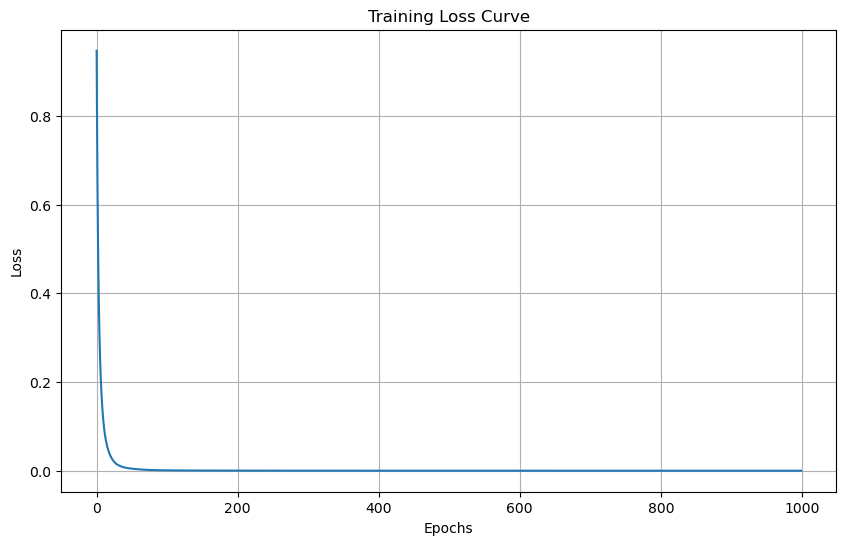


Class mapping:
Class 0: e
Class 1: p


In [46]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Print class mapping
print("\nClass mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"Class {i}: {class_name}")